<a href="https://colab.research.google.com/github/ChaosT800/ML_NIDSAPP/blob/main/ML_based_NIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download the NSL-KDD dataset directly from GitHub
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt -O KDDTrain+.txt
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt -O KDDTest+.txt

print("✅ Dataset downloaded successfully!")

✅ Dataset downloaded successfully!


In [ ]:
import pandas as pd

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

train_df = pd.read_csv("KDDTrain+.txt", header=None, names=col_names)
test_df  = pd.read_csv("KDDTest+.txt",  header=None, names=col_names)

print(f"✅ Training data shape: {train_df.shape}")
print(f"✅ Testing data shape:  {test_df.shape}")

✅ Training data shape: (125973, 43)
✅ Testing data shape:  (22544, 43)


In [ ]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
print("Unique labels in training set:")
print(train_df['label'].unique())

Unique labels in training set:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [ ]:
train_df.drop('difficulty', axis=1, inplace=True)
test_df.drop('difficulty', axis=1, inplace=True)

print("✅ Difficulty column dropped!")
print(f"New shape → Train: {train_df.shape}, Test: {test_df.shape}")

✅ Difficulty column dropped!
New shape → Train: (125973, 42), Test: (22544, 42)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
attack_map = {
    'normal': 'Normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'worm': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'httptunnel': 'U2R', 'ps': 'U2R',
    'sqlattack': 'U2R', 'xterm': 'U2R'
}

train_df['attack_category'] = train_df['label'].map(attack_map)
test_df['attack_category']  = test_df['label'].map(attack_map)

print("✅ Attack categories mapped!")
print(train_df['attack_category'].value_counts())

✅ Attack categories mapped!
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


/tmp/ipykernel_3745/1687566142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='attack_category',


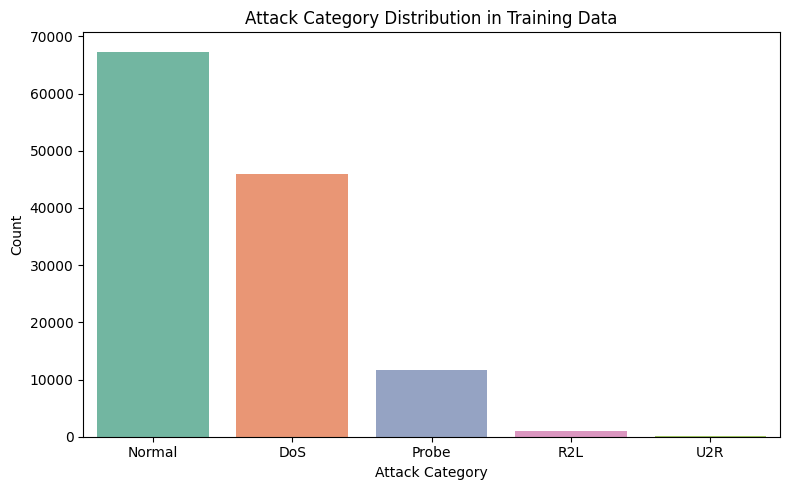

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='attack_category',
              order=train_df['attack_category'].value_counts().index,
              palette='Set2')
plt.title('Attack Category Distribution in Training Data')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3745/825136074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='protocol_type', palette='Set1')


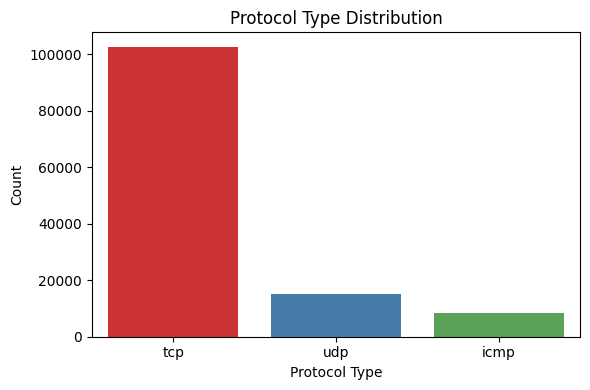

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='protocol_type', palette='Set1')
plt.title('Protocol Type Distribution')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values in training data:")
print(train_df.isnull().sum().sum(), "total missing values")

print("\nMissing values in testing data:")
print(test_df.isnull().sum().sum(), "total missing values")

Missing values in training data:
0 total missing values

Missing values in testing data:
0 total missing values


In [ ]:
# These 3 columns have text values — model can't read text, only numbers
categorical_cols = ['protocol_type', 'service', 'flag']

print("Categorical columns:")
for col in categorical_cols:
    print(f"  {col} → {train_df[col].nunique()} unique values")

Categorical columns:
  protocol_type → 3 unique values
  service → 70 unique values
  flag → 11 unique values


In [ ]:
# Convert categorical text columns into binary number columns
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df  = pd.get_dummies(test_df,  columns=categorical_cols)

print("✅ One Hot Encoding done!")
print(f"Train shape after encoding: {train_df.shape}")
print(f"Test shape after encoding:  {test_df.shape}")

✅ One Hot Encoding done!
Train shape after encoding: (125973, 124)
Test shape after encoding:  (22544, 118)


In [ ]:
# Test data might have different dummy columns than train — align them
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

print("✅ Columns aligned!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

✅ Columns aligned!
Train shape: (125973, 124)
Test shape:  (22544, 124)


In [ ]:
# X = features (everything except label columns)
# y = target (what we want to predict)

drop_cols = ['label', 'attack_category']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['attack_category']

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['attack_category']

print("✅ X and y prepared!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nClasses: {y_train.unique()}")

✅ X and y prepared!
X_train shape: (125973, 122)
X_test shape:  (22544, 122)

Classes: ['Normal' 'DoS' 'R2L' 'Probe' 'U2R']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print("✅ Normalization done!")
print(f"Min value in X_train: {X_train.min().min()}")
print(f"Max value in X_train: {X_train.max().max()}")

✅ Normalization done!
Min value in X_train: 0.0
Max value in X_train: 1.0


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import numpy as np

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Use only 10% of training data
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.90, random_state=42)
for train_index, _ in sss.split(X_train, y_train):
    X_train_sample = X_train.iloc[train_index]
    y_train_sample = y_train.iloc[train_index]

print(f"✅ Using {X_train_sample.shape[0]} samples for RFE")

rf = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)

rfe_rf = RFECV(estimator=rf, step=5, cv=3, scoring='accuracy', n_jobs=-1)
rfe_rf.fit(X_train_sample, y_train_sample)

print("✅ RFE with Random Forest done!")
print(f"Optimal number of features: {rfe_rf.n_features_}")

rf_selected_features = X_train.columns[rfe_rf.support_].tolist()
print(f"\nSelected features:\n{rf_selected_features}")

✅ Using 12597 samples for RFE
✅ RFE with Random Forest done!
Optimal number of features: 72

Selected features:
['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'num_root', 'num_file_creations', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_auth', 'service_daytime', 'service_domain', 'service_domain_u', 'service_eco_i', 'service_ecr_i', 'service_finger', 'service_ftp', 'service_ftp_data', 'service_http', '

In [ ]:
print("Starting RFE with SVM... ⏳")

svm = LinearSVC(max_iter=500, random_state=42)

rfe_svm = RFECV(estimator=svm, step=5, cv=3, scoring='accuracy', n_jobs=-1)
rfe_svm.fit(X_train_sample, y_train_sample)

print("✅ RFE with SVM done!")
print(f"Optimal number of features: {rfe_svm.n_features_}")

svm_selected_features = X_train.columns[rfe_svm.support_].tolist()
print(f"\nSelected features:\n{svm_selected_features}")

Starting RFE with SVM... ⏳
✅ RFE with SVM done!
Optimal number of features: 72

Selected features:
['duration', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'root_shell', 'su_attempted', 'num_file_creations', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_auth', 'service_ctf', 'service_daytime', 'service_domain', 'service_domain_u', 'service_eco_i', 'service_ecr_i', 'service_finger', 'service_ftp', 'service_ftp_data', 'service_http', 'service_login', 'service_name', 'service_netstat', 'service

In [ ]:
X_train_rf  = X_train[rf_selected_features]
X_test_rf   = X_test[rf_selected_features]

X_train_svm = X_train[svm_selected_features]
X_test_svm  = X_test[svm_selected_features]

print("✅ Feature filtered datasets ready!")
print(f"RF  → X_train: {X_train_rf.shape},  X_test: {X_test_rf.shape}")
print(f"SVM → X_train: {X_train_svm.shape}, X_test: {X_test_svm.shape}")

✅ Feature filtered datasets ready!
RF  → X_train: (125973, 72),  X_test: (22544, 72)
SVM → X_train: (125973, 72), X_test: (22544, 72)


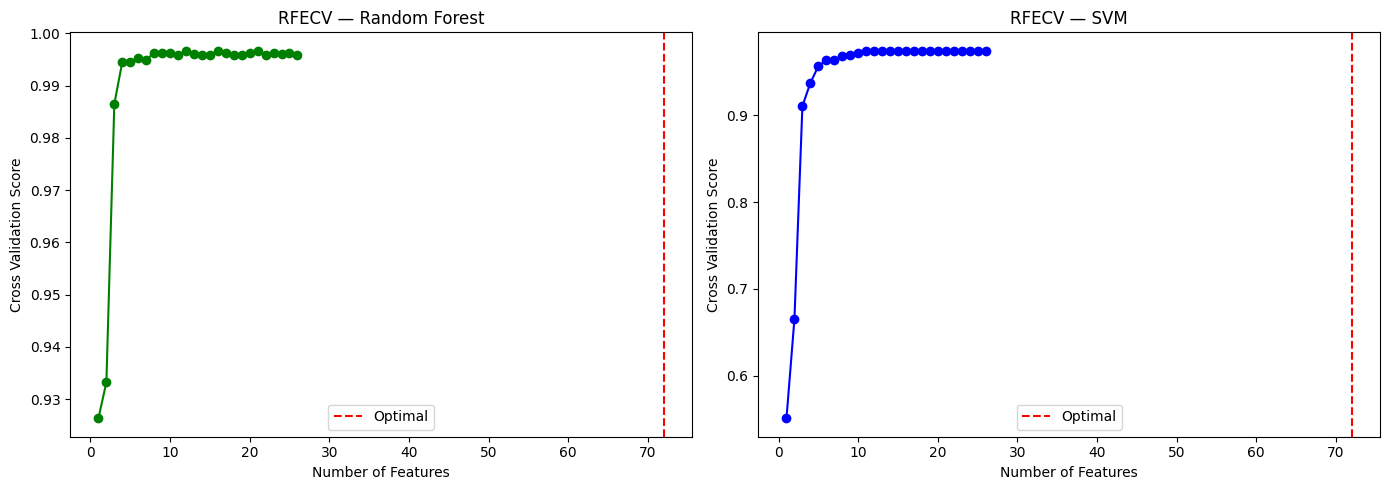

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(rfe_rf.cv_results_['mean_test_score']) + 1),
             rfe_rf.cv_results_['mean_test_score'], marker='o', color='green')
axes[0].set_title('RFECV — Random Forest')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Cross Validation Score')
axes[0].axvline(x=rfe_rf.n_features_, color='red', linestyle='--', label='Optimal')
axes[0].legend()

axes[1].plot(range(1, len(rfe_svm.cv_results_['mean_test_score']) + 1),
             rfe_svm.cv_results_['mean_test_score'], marker='o', color='blue')
axes[1].set_title('RFECV — SVM')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cross Validation Score')
axes[1].axvline(x=rfe_svm.n_features_, color='red', linestyle='--', label='Optimal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import time

# Train Random Forest on ALL features
print("Training Random Forest on all features... ⏳")
start = time.time()

rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)

end = time.time()
print(f"✅ Random Forest (all features) trained in {round(end-start, 2)} seconds!")

Training Random Forest on all features... ⏳
✅ Random Forest (all features) trained in 9.4 seconds!


In [ ]:
print("Training Random Forest on RFE selected features... ⏳")
start = time.time()

rf_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_rfe.fit(X_train_rf, y_train)

end = time.time()
print(f"✅ Random Forest (RFE features) trained in {round(end-start, 2)} seconds!")

Training Random Forest on RFE selected features... ⏳
✅ Random Forest (RFE features) trained in 8.72 seconds!


In [ ]:
print("Training SVM on all features... ⏳")
start = time.time()

svm_all = LinearSVC(max_iter=1000, random_state=42)
svm_all.fit(X_train, y_train)

end = time.time()
print(f"✅ SVM (all features) trained in {round(end-start, 2)} seconds!")

Training SVM on all features... ⏳
✅ SVM (all features) trained in 2.64 seconds!


In [ ]:
print("Training SVM on RFE selected features... ⏳")
start = time.time()

svm_rfe = LinearSVC(max_iter=1000, random_state=42)
svm_rfe.fit(X_train_svm, y_train)

end = time.time()
print(f"✅ SVM (RFE features) trained in {round(end-start, 2)} seconds!")

Training SVM on RFE selected features... ⏳
✅ SVM (RFE features) trained in 2.19 seconds!


In [ ]:
print("=" * 40)
print("      ALL 4 MODELS TRAINED! ✅")
print("=" * 40)
print(f"1. Random Forest — All Features  ✅")
print(f"2. Random Forest — RFE Features  ✅")
print(f"3. SVM           — All Features  ✅")
print(f"4. SVM           — RFE Features  ✅")
print("=" * 40)
print("\nReady for Evaluation! 🚀")

      ALL 4 MODELS TRAINED! ✅
1. Random Forest — All Features  ✅
2. Random Forest — RFE Features  ✅
3. SVM           — All Features  ✅
4. SVM           — RFE Features  ✅

Ready for Evaluation! 🚀


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("✅ Evaluation libraries imported!")

✅ Evaluation libraries imported!


In [ ]:
# Predictions from all 4 models
y_pred_rf_all  = rf_all.predict(X_test)
y_pred_rf_rfe  = rf_rfe.predict(X_test_rf)
y_pred_svm_all = svm_all.predict(X_test)
y_pred_svm_rfe = svm_rfe.predict(X_test_svm)

print("✅ Predictions done for all 4 models!")

✅ Predictions done for all 4 models!


In [ ]:
models = {
    'RF  — All Features' : y_pred_rf_all,
    'RF  — RFE Features' : y_pred_rf_rfe,
    'SVM — All Features' : y_pred_svm_all,
    'SVM — RFE Features' : y_pred_svm_rfe
}

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10}")
print("=" * 55)

for model_name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    print(f"{model_name:<25} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}%")

print("=" * 55)

Model                       Accuracy  Precision     Recall
RF  — All Features            75.07%     80.46%     75.07%
RF  — RFE Features            76.50%     81.84%     76.50%
SVM — All Features            74.37%     73.90%     74.37%
SVM — RFE Features            74.89%     78.47%     74.89%


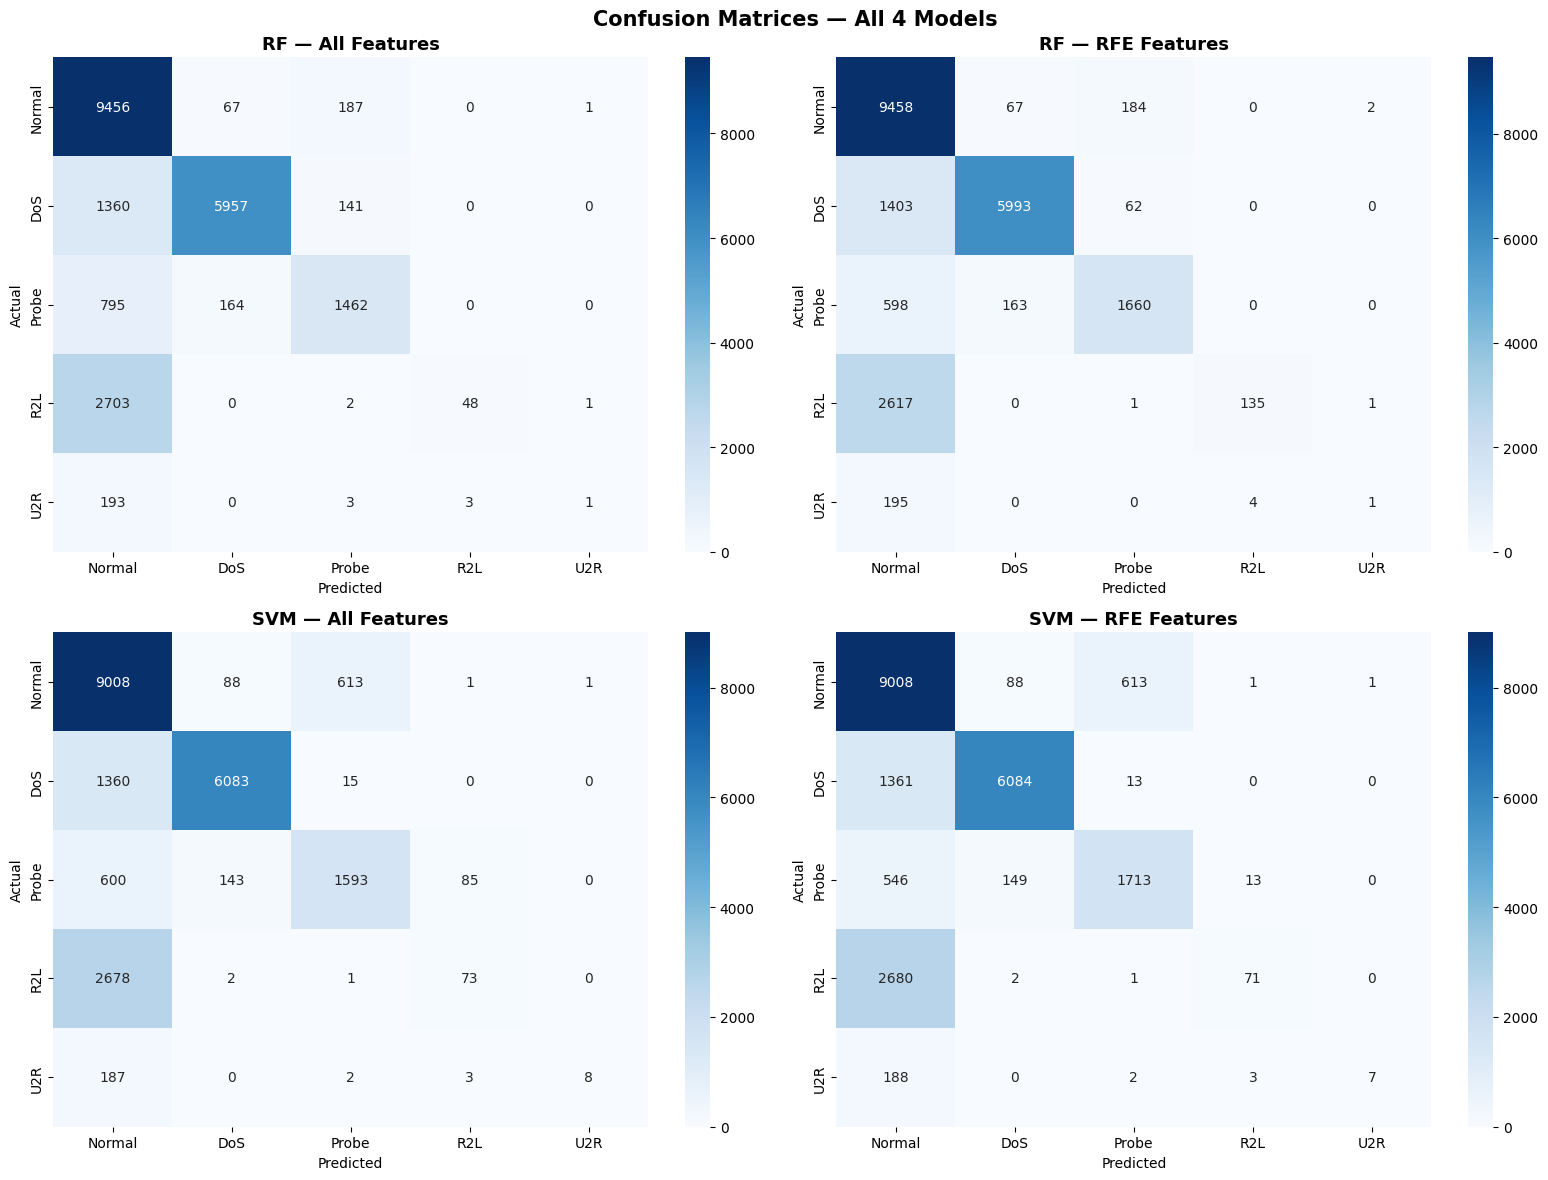

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

model_preds = [
    ('RF — All Features',  y_pred_rf_all),
    ('RF — RFE Features',  y_pred_rf_rfe),
    ('SVM — All Features', y_pred_svm_all),
    ('SVM — RFE Features', y_pred_svm_rfe)
]

for ax, (title, y_pred) in zip(axes.flatten(), model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

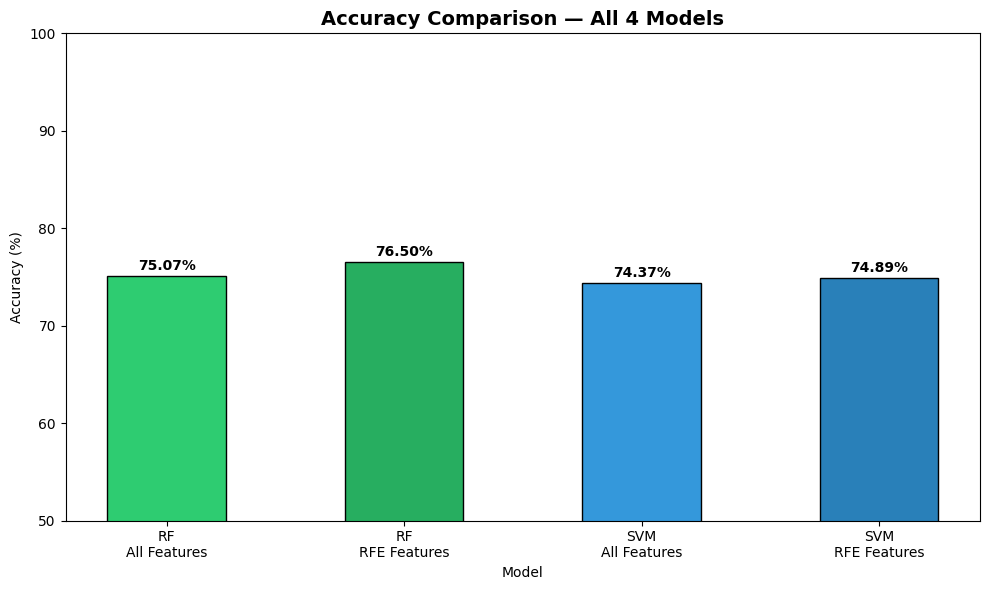

In [ ]:
model_names = ['RF\nAll Features', 'RF\nRFE Features',
               'SVM\nAll Features', 'SVM\nRFE Features']

accuracies = [
    accuracy_score(y_test, y_pred_rf_all)  * 100,
    accuracy_score(y_test, y_pred_rf_rfe)  * 100,
    accuracy_score(y_test, y_pred_svm_all) * 100,
    accuracy_score(y_test, y_pred_svm_rfe) * 100
]

colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9']

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='black')
plt.ylim(50, 100)
plt.title('Accuracy Comparison — All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
model_preds = {
    'RF — All Features'  : y_pred_rf_all,
    'RF — RFE Features'  : y_pred_rf_rfe,
    'SVM — All Features' : y_pred_svm_all,
    'SVM — RFE Features' : y_pred_svm_rfe
}

for model_name, y_pred in model_preds.items():
    print("=" * 55)
    print(f"  {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
          target_names=labels, zero_division=0))

  RF — All Features
              precision    recall  f1-score   support

      Normal       0.96      0.80      0.87      7458
         DoS       0.65      0.97      0.78      9711
       Probe       0.81      0.60      0.69      2421
         R2L       0.94      0.02      0.03      2754
         U2R       0.33      0.01      0.01       200

    accuracy                           0.75     22544
   macro avg       0.74      0.48      0.48     22544
weighted avg       0.80      0.75      0.70     22544

  RF — RFE Features
              precision    recall  f1-score   support

      Normal       0.96      0.80      0.88      7458
         DoS       0.66      0.97      0.79      9711
       Probe       0.87      0.69      0.77      2421
         R2L       0.97      0.05      0.09      2754
         U2R       0.25      0.01      0.01       200

    accuracy                           0.77     22544
   macro avg       0.74      0.50      0.51     22544
weighted avg       0.82      0.77    

In [ ]:
import pickle
import os

# Create a folder to store models
os.makedirs('models', exist_ok=True)

# Save all 4 models
with open('models/rf_all.pkl', 'wb') as f:
    pickle.dump(rf_all, f)

with open('models/rf_rfe.pkl', 'wb') as f:
    pickle.dump(rf_rfe, f)

with open('models/svm_all.pkl', 'wb') as f:
    pickle.dump(svm_all, f)

with open('models/svm_rfe.pkl', 'wb') as f:
    pickle.dump(svm_rfe, f)

print("✅ All 4 models saved successfully!")

✅ All 4 models saved successfully!


In [ ]:
# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature lists
with open('models/rf_selected_features.pkl', 'wb') as f:
    pickle.dump(rf_selected_features, f)

with open('models/svm_selected_features.pkl', 'wb') as f:
    pickle.dump(svm_selected_features, f)

# Save full feature list
with open('models/all_features.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("✅ Scaler and feature lists saved!")

✅ Scaler and feature lists saved!


In [ ]:
print("Files saved in models/ folder:")
print("=" * 35)
for file in os.listdir('models'):
    size = os.path.getsize(f'models/{file}')
    print(f"  {file:<35} {size/1024:.1f} KB")
print("=" * 35)
print("✅ All files verified!")

Files saved in models/ folder:
  svm_selected_features.pkl           1.2 KB
  rf_rfe.pkl                          11711.2 KB
  all_features.pkl                    2.0 KB
  scaler.pkl                          7.3 KB
  svm_all.pkl                         7.4 KB
  rf_all.pkl                          13099.5 KB
  rf_selected_features.pkl            1.2 KB
  svm_rfe.pkl                         4.6 KB
✅ All files verified!


In [ ]:
from google.colab import files
import zipfile

# Zip all models into one file
with zipfile.ZipFile('NIDS_models.zip', 'w') as zipf:
    for file in os.listdir('models'):
        zipf.write(f'models/{file}', file)

print("✅ Models zipped!")

# Download to your laptop
files.download('NIDS_models.zip')
print("✅ Download started!")

✅ Models zipped!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [ ]:
# Get a real DoS attack record from test data
dos_sample = test_df[test_df['attack_category'] == 'DoS'].iloc[0]
print("Real DoS record values:")
print(dos_sample[['duration', 'src_bytes', 'dst_bytes',
                   'count', 'srv_count',
                   'serror_rate', 'srv_serror_rate', 'rerror_rate',
                   'same_srv_rate', 'diff_srv_rate',
                   'dst_host_count', 'dst_host_srv_count',
                   'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
                   'dst_host_serror_rate', 'dst_host_srv_serror_rate',
                   'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
                   'attack_category',
                   'protocol_type_tcp', 'protocol_type_udp', 'protocol_type_icmp',
                   'service_http', 'service_private', 'service_ftp',
                   'flag_SF', 'flag_S0', 'flag_REJ']])

Real DoS record values:
duration                        0
src_bytes                       0
dst_bytes                       0
count                         229
srv_count                      10
serror_rate                   0.0
srv_serror_rate               0.0
rerror_rate                   1.0
same_srv_rate                0.04
diff_srv_rate                0.06
dst_host_count                255
dst_host_srv_count             10
dst_host_same_srv_rate       0.04
dst_host_diff_srv_rate       0.06
dst_host_serror_rate          0.0
dst_host_srv_serror_rate      0.0
dst_host_rerror_rate          1.0
dst_host_srv_rerror_rate      1.0
attack_category               DoS
protocol_type_tcp            True
protocol_type_udp           False
protocol_type_icmp          False
service_http                False
service_private              True
service_ftp                 False
flag_SF                     False
flag_S0                     False
flag_REJ                     True
Name: 0, dtype: object
